In [60]:
# ==== 설정 ====
import json, numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.stats import rankdata

# 파일 경로
# PATH_CHL  = "./DATA/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m_1760375673183.nc"
# PATH_MHW  = "./DATA/mhw_daily_running_1982_2025.nc"
# PATH_JSON = "./DATA/Korean_sea_lat_lon.json"

PATH_CHL  = "C:/Users/User/Desktop/ddong/DATA/cmems_mod_glo_bgc-pft_anfc_0.25deg_P1D-m_1760375673183.nc"
PATH_MHW  = "C:/Users/User/Desktop/ddong/DATA/mhw_daily_running_1982_2025.nc"
PATH_JSON = "C:/Users/User/Desktop/ddong/DATA/Korean_sea_lat_lon.json"


REGION_KEY = "한반도"   # '남해','동해','서해','한반도','동현' 등 JSON 키 중에서 선택
HIGH_Q, LOW_Q = 0.75, 0.25   # 상/하위 분위(강/약 달 라벨)
DMIN = 12                    # 월내 상관 계산 최소 공통 유효일수
METHOD = "pearson"           # 'pearson' 또는 'spearman'
TOP_FRAC = 0.2               # 그림에서 |가중치| 상위 p만 표시 (None이면 전체)

In [61]:
# ==== 공용 유틸 ====
DIRS8 = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

def std_latlon(ds):
    rn = {}
    for k in ds.coords:
        kl = k.lower()
        if kl in ("lat","latitude"): rn[k] = "lat"
        if kl in ("lon","longitude"): rn[k] = "lon"
    return ds.rename(rn) if rn else ds

def build_edges_from_mask(valid2d: np.ndarray):
    m, n = valid2d.shape
    node_id = -np.ones((m,n), int)
    coords = [(r,c) for r in range(m) for c in range(n) if valid2d[r,c]]
    for i,(r,c) in enumerate(coords): node_id[r,c] = i
    edges = []
    for r,c in coords:
        u = node_id[r,c]
        for dr,dc in DIRS8:
            rr,cc = r+dr, c+dc
            if 0<=rr<m and 0<=cc<n and valid2d[rr,cc]:
                v = node_id[rr,cc]
                if u < v: edges.append((u,v))
    return np.array(edges), node_id, coords

def corr_pairwise(x, y, method="pearson", dmin=12):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < dmin: return np.nan, 0
    xi, yi = x[m], y[m]
    if method == "spearman":
        xi = rankdata(xi).astype(float); yi = rankdata(yi).astype(float)
    xi = (xi - xi.mean())/(xi.std(ddof=1)+1e-12)
    yi = (yi - yi.mean())/(yi.std(ddof=1)+1e-12)
    r = float((xi @ yi)/(len(xi)-1))
    return r, m.sum()

def month_edge_weights(chl_daily, month_key, node_id, edges, method="pearson", dmin_per_month=DMIN):
    # pandas 대신 numpy로 변환 → month 키
    t = np.asarray(chl_daily.time.values).astype('datetime64[ns]')
    tM = t.astype('datetime64[M]')

    # 해당 월 데이터만 슬라이스
    sub = chl_daily.sel(time=(tM == month_key))
    W = sub.sizes.get("time", 0)
    if W == 0:
        # 해당 월에 일자료가 없으면 안전하게 NaN 반환
        return np.full(len(edges), np.nan, float), np.zeros(len(edges), int)

    N = node_id.max() + 1
    A = np.full((W, N), np.nan, float)
    for (r, c), i in np.ndenumerate(node_id):
        if i >= 0:
            A[:, i] = sub[:, r, c].values

    r_list = np.empty(len(edges), float)
    n_list = np.empty(len(edges), int)
    for k, (u, v) in enumerate(edges):
        mask = np.isfinite(A[:, u]) & np.isfinite(A[:, v])
        n = int(mask.sum())
        n_list[k] = n
        if n < dmin_per_month:
            r_list[k] = np.nan
            continue

        x = A[mask, u]; y = A[mask, v]
        if method == "spearman":
            from scipy.stats import rankdata
            x = rankdata(x).astype(float); y = rankdata(y).astype(float)
        x = (x - x.mean()) / (x.std(ddof=1) + 1e-12)
        y = (y - y.mean()) / (y.std(ddof=1) + 1e-12)
        r_list[k] = float((x @ y) / (n - 1))
    return r_list, n_list

def fisher_z(r): r = np.clip(r, -0.999999, 0.999999); return 0.5*np.log((1+r)/(1-r))
def inv_fisher_z(z): return np.tanh(z)

def plot_net(title, edges, coords_rc, lat2d, lon2d, weights, node_field=None, top_frac=0.2):
    # lat/lon이 1D인지 2D인지 판별
    latv = np.asarray(lat2d.values)
    lonv = np.asarray(lon2d.values)
    lat_is_1d = latv.ndim == 1
    lon_is_1d = lonv.ndim == 1

    # 노드별 (x=lon, y=lat) 좌표 생성
    if lat_is_1d and lon_is_1d:
        # 1D 좌표: (r,c) -> (lon[c], lat[r])
        xy = {i: (float(lonv[c]), float(latv[r])) for i, (r, c) in enumerate(coords_rc)}
    else:
        # 2D 좌표: (r,c) -> (lon[r,c], lat[r,c])
        xy = {i: (float(lonv[r, c]), float(latv[r, c])) for i, (r, c) in enumerate(coords_rc)}

    # 엣지 선택/세그먼트 생성
    w = np.array(weights, float)
    ok = np.isfinite(w)
    if top_frac is not None:
        k = max(1, int(np.ceil(np.sum(ok)*top_frac)))
        idx = np.argsort(np.abs(w[ok]))[-k:]
        eplot = np.array(edges)[ok][idx]; wplot = w[ok][idx]
    else:
        eplot = np.array(edges)[ok]; wplot = w[ok]

    segs = [[xy[u], xy[v]] for (u, v) in eplot]
    lc = LineCollection(segs, linewidths=1 + 5*np.abs(wplot), cmap="coolwarm", array=wplot, alpha=0.9)

    # 그리기
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.add_collection(lc)

    xs = [xy[i][0] for i in range(len(coords_rc))]
    ys = [xy[i][1] for i in range(len(coords_rc))]
    if node_field is not None:
        sc = ax.scatter(xs, ys, c=node_field, s=14, cmap="viridis", edgecolor="k", linewidths=0.1, zorder=3)
        plt.colorbar(sc, ax=ax, shrink=0.8, label="Monthly Chl-a (anomaly)")
    else:
        ax.scatter(xs, ys, s=12, c="#333", zorder=3)

    plt.colorbar(lc, ax=ax, shrink=0.8, label="Edge weight (r)")
    ax.set_title(title); ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_aspect("equal", "box"); plt.tight_layout(); plt.show()


[라벨] High=12개월 / Low=12개월
[노드/엣지] nodes=534, edges=1881


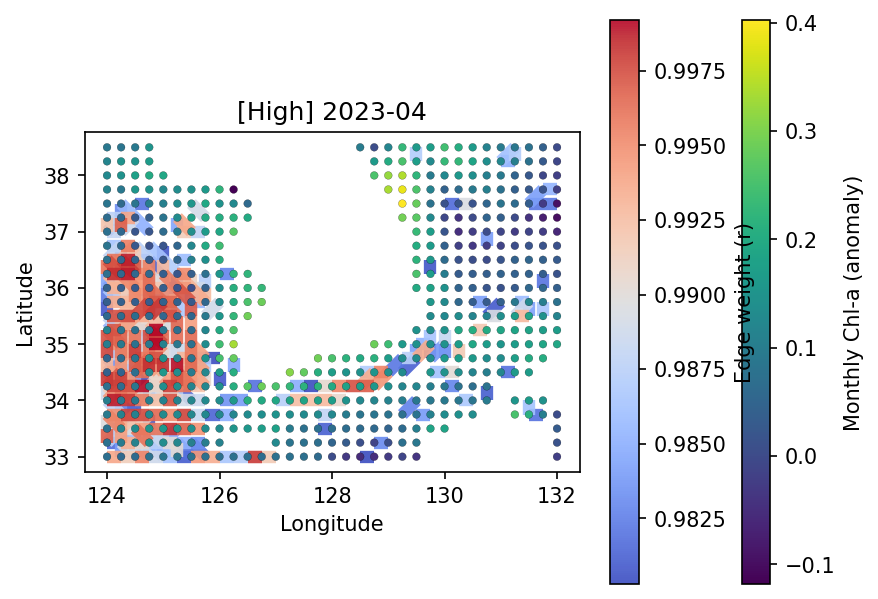

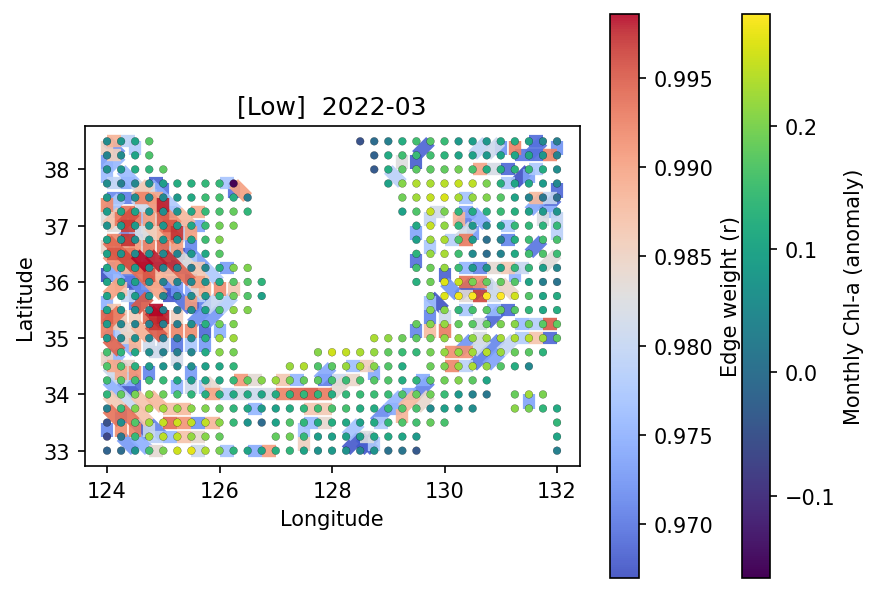

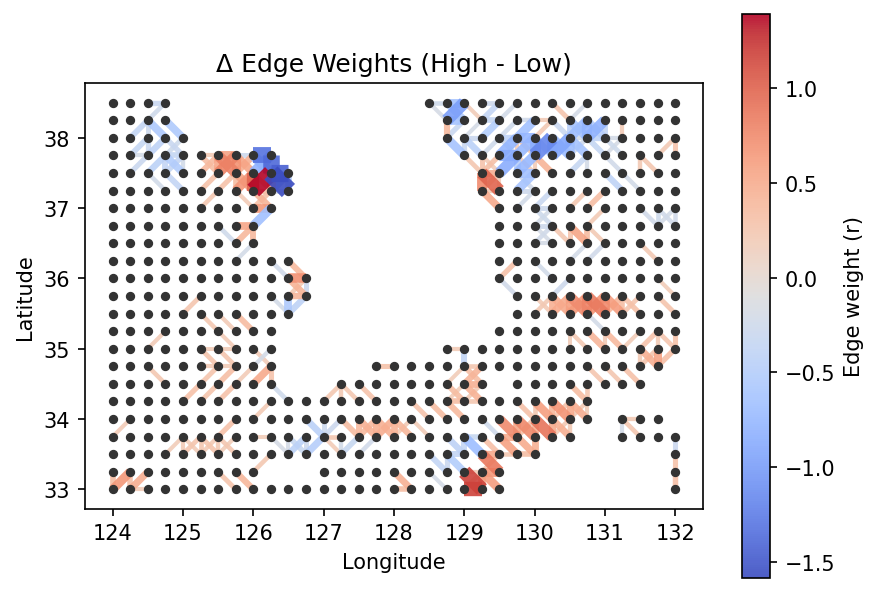

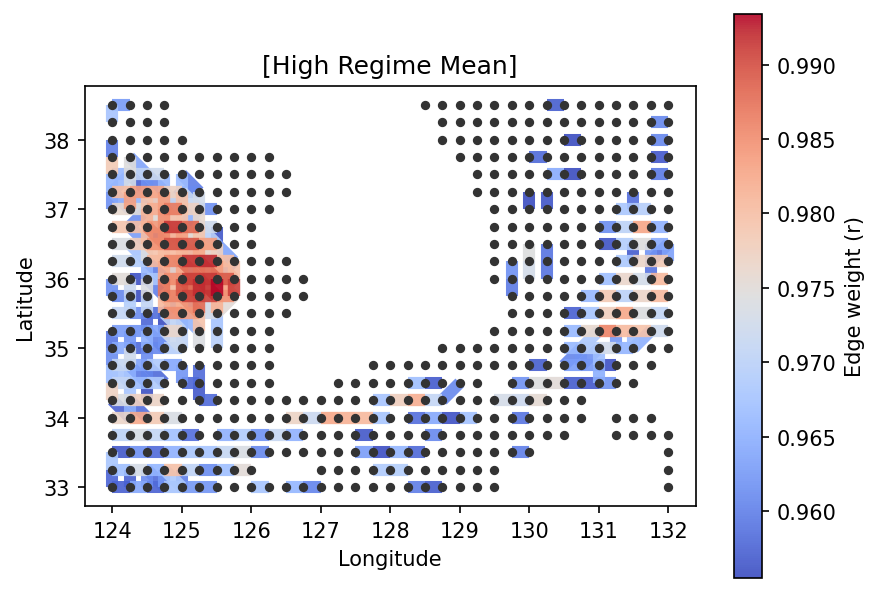

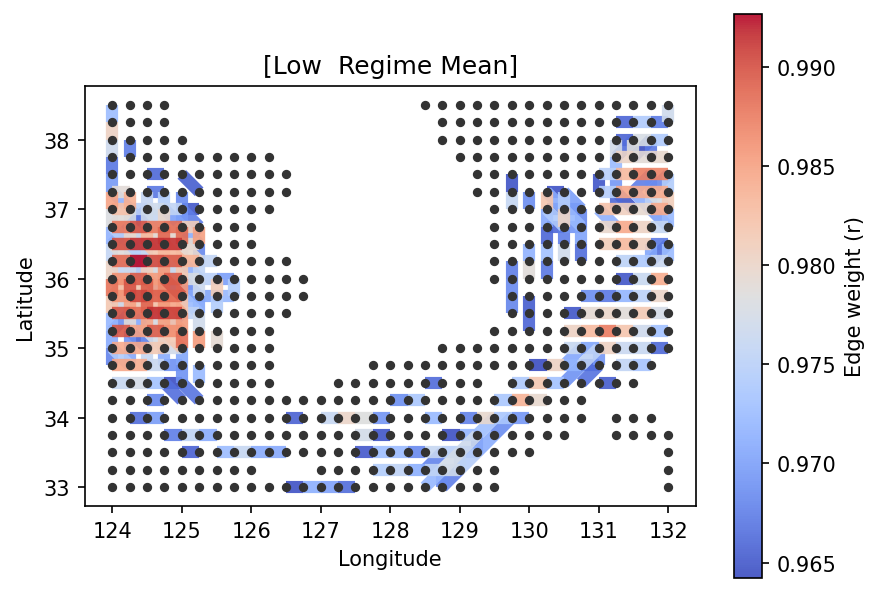

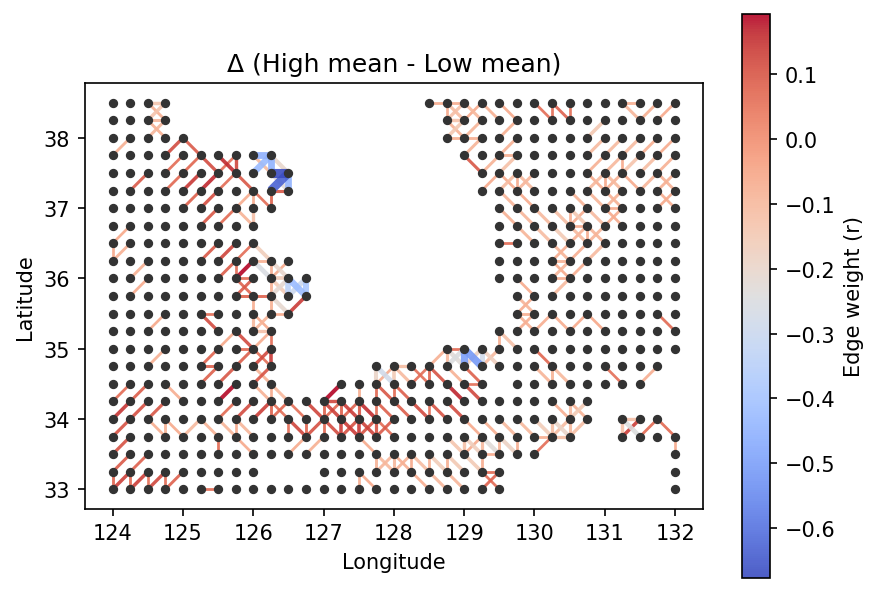

In [62]:
# ==== 1) 데이터 로드 ====
# 영역 박스
with open(PATH_JSON, "r", encoding="utf-8") as f:
    reg = json.load(f)[REGION_KEY]
lat_min, lat_max = reg["lat_range"]; lon_min, lon_max = reg["lon_range"]

# 엽록소(일별) — 좌표 통일 + 수심 가장 얕은 층 사용
ds_chl = std_latlon(xr.open_dataset(PATH_CHL, mask_and_scale=True))
chl3d  = ds_chl["chl"]                             # 파일에 'chl' 존재 확인됨
chl3d  = chl3d.isel(depth=0)                       # 가장 얕은 층(첫 층). 필요시 sel(depth=ds_chl['depth'].min())로 교체 가능
chl3d  = chl3d.sel(lat=slice(lat_min,lat_max), lon=slice(lon_min,lon_max))

# 권장 전처리: log1p + 월별 클라이모 제거 → anomaly
chl_log  = xr.apply_ufunc(np.log1p, chl3d.where(np.isfinite(chl3d)))
clim     = chl_log.groupby("time.month").mean("time")
chl_anom = chl_log.groupby("time.month") - clim
chl_month = chl_anom.resample(time="MS").mean().rename(time="month")   # (month, lat, lon) — 노드 색용

# MHW(일별) — intensity로 라벨링
ds_mhw = std_latlon(xr.open_dataset(PATH_MHW, mask_and_scale=True))
I_d    = ds_mhw["mhw_running"].sel(lat=slice(lat_min,lat_max), lon=slice(lon_min,lon_max))
I_m    = I_d.resample(time="MS").sum().rename(time="month")            # 월 누적 강도

# 공통 월 교집합 정렬 (엽록소 월평균과 MHW 월지표)
months = np.intersect1d(chl_month["month"].values, I_m["month"].values)
chl_month = chl_month.sel(month=months)
I_m       = I_m.sel(month=months)

# ==== 2) 월 라벨(High/Low) ====
I_scalar = I_m.mean(("lat","lon"), skipna=True)    # 영역평균 월 누적 강도
thrH, thrL = float(I_scalar.quantile(HIGH_Q)), float(I_scalar.quantile(LOW_Q))
months_high = I_scalar["month"].values[I_scalar.values >= thrH]
months_low  = I_scalar["month"].values[I_scalar.values <= thrL]
print(f"[라벨] High={len(months_high)}개월 / Low={len(months_low)}개월")

# ==== 3) 공통 마스크 & 8-이웃 엣지 ====
def common_mask(chl_daily, months, dmin=DMIN):
    # BEFORE (에러 원인)
    # tM = pd.to_datetime(chl_daily.time.values).astype("datetime64[M]")

    # AFTER (안전한 변환: numpy -> month 단위)
    t = np.asarray(chl_daily.time.values).astype('datetime64[ns]')  # numpy datetime64[ns]
    tM = t.astype('datetime64[M]')                                  # month 키

    mask = None
    for m in months:
        sub = chl_daily.sel(time=(tM == m))
        v = np.isfinite(sub).sum("time").values >= dmin
        mask = v if mask is None else (mask & v)
    return mask.astype(bool)

valid2d = common_mask(chl_anom, np.unique(np.concatenate([months_high, months_low])), DMIN)
edges, node_id, coords_rc = build_edges_from_mask(valid2d)
lat2d, lon2d = chl_month["lat"], chl_month["lon"]
print(f"[노드/엣지] nodes={len(coords_rc)}, edges={len(edges)}")

# ==== 4) 예시: 강/약 한 달 네트워크 & Δ ====
mH, mL = months_high[0], months_low[0]
wH,_ = month_edge_weights(chl_anom, mH, node_id, edges, method=METHOD, dmin_per_month=DMIN)
wL,_ = month_edge_weights(chl_anom, mL, node_id, edges, method=METHOD, dmin_per_month=DMIN)

def month_node_field(chl_monthly, month_key, node_id):
    cm = chl_monthly.sel(month=month_key)
    out = np.full(node_id.max()+1, np.nan, float)
    for (r,c), i in np.ndenumerate(node_id):
        if i>=0: out[i] = float(cm.values[r,c])
    return out

plot_net(f"[High] {np.datetime_as_string(mH,'M')}", edges, coords_rc, lat2d, lon2d, wH, month_node_field(chl_month, mH, node_id), TOP_FRAC)
plot_net(f"[Low]  {np.datetime_as_string(mL,'M')}", edges, coords_rc, lat2d, lon2d, wL, month_node_field(chl_month, mL, node_id), TOP_FRAC)
plot_net("Δ Edge Weights (High - Low)", edges, coords_rc, lat2d, lon2d, np.array(wH)-np.array(wL), None, TOP_FRAC)

# ==== 5) 레짐 평균(Fisher z 가중평균) & Δ ====
def regime_mean(chl_daily, months_list):
    Z = np.zeros(len(edges)); W = np.zeros(len(edges))
    for m in months_list:
        r,n = month_edge_weights(chl_daily, m, node_id, edges, method=METHOD, dmin_per_month=DMIN)
        ok = np.isfinite(r) & (n>=DMIN)
        if not np.any(ok): continue
        Z[ok] += fisher_z(r[ok]) * (n[ok]-3)
        W[ok] += np.maximum(n[ok]-3, 0)
    zbar = np.where(W>0, Z/W, np.nan)
    return inv_fisher_z(zbar)

wH_mean = regime_mean(chl_anom, months_high)
wL_mean = regime_mean(chl_anom, months_low)

plot_net("[High Regime Mean]", edges, coords_rc, lat2d, lon2d, wH_mean, None, TOP_FRAC)
plot_net("[Low  Regime Mean]", edges, coords_rc, lat2d, lon2d, wL_mean, None, TOP_FRAC)
plot_net("Δ (High mean - Low mean)", edges, coords_rc, lat2d, lon2d, wH_mean - wL_mean, None, TOP_FRAC)